## This notebook documents the analysis reported for multimodal impulsivity prediction

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=2,style='whitegrid')
from scipy.stats import pearsonr, spearmanr
import sys
import statsmodels.api as sm

### Questionnnaire on impulsivity

In [2]:
#questionnaire data
quest_file = r'data/patient_questionnaire_scores_35pat.csv'
quest_pd   = pd.read_csv(quest_file)
quest_pd.tail()

,MIND-ID,BIS-attentionLack_1order_score,BIS-cognitiveInstability_1order_score,BIS-AttentionalImpuls_2order_score,BIS-motorImpuls_1order_score,BIS-perseveranceLack_1order_score,BIS-MotorImpuls_2order_score,BIS-selfcontrolLack_1order_score,BIS-cognitiveComplexity_1order_score,BIS-NonPlanning_2order_score,BIS-total_score
30,P-031,11,9,20,12,5,17,11,12,23,60
31,NaN,0,0,0,0,0,0,0,0,0,0
32,P-033,13,5,18,15,12,27,21,18,39,84
33,P-034,18,12,30,22,9,31,22,20,42,103
34,P-035,13,12,25,19,9,28,13,8,21,74


In [3]:
bis_cols = [x for x in quest_pd.columns.values if x.startswith('BIS-') and (x.endswith('-total_score') or\
                                                            x.endswith('2order_score'))]

In [4]:
bis_score_range = {'BIS-AttentionalImpuls_2order_score':8,
 'BIS-MotorImpuls_2order_score':11,
 'BIS-NonPlanning_2order_score':11,
 'BIS-total_score':30}

In [5]:
bis_quest_data = quest_pd[bis_cols]

quest_name = {'BIS-AttentionalImpuls_2order_score':'Attentional',
 'BIS-MotorImpuls_2order_score':'Motor',
 'BIS-NonPlanning_2order_score':'Nonplanning',
 'BIS-total_score':'Total'}

bis_quest_data = bis_quest_data.rename(quest_name,axis=1)

### Behavioral tests

In [6]:
#flanker results
flanker_file = r'data/flanker_res_pd_35pat_paper.csv'

flanker_pd = pd.read_csv(flanker_file,index_col=0)
flanker_pd.head()

,MIND-ID,correct_response,error_rate,error_rate_incongr,overall_RTmean,congruent_RTmean,incongruent_RTmean,neutral_RTmean,correctresp_RTmean,flankereffect_RTmean,flankereffect_RT_mean_norm,num_trial
0,P-001,0.862069,0.137931,0.146341,436.761468,404.512821,457.550000,477.909091,458.395604,53.037179,0.131114,145
1,P-002,0.751724,0.248276,0.088235,364.282759,353.121951,387.147059,347.463415,361.697248,34.025108,0.096355,145
2,P-003,0.634483,0.365517,0.256410,384.320896,349.222222,425.675676,369.111111,394.989011,76.453453,0.218925,145
3,P-004,0.310345,0.689655,0.595238,409.830769,388.516129,413.000000,425.000000,372.674419,24.483871,0.063019,145
4,P-005,0.917241,0.082759,0.054054,433.150442,421.717949,422.194444,462.666667,434.383178,0.476496,0.001130,145


In [7]:
len(flanker_pd['MIND-ID'])

30

In [8]:
#imt/dmt results
imtdmt_file = r'data/imtdmt_res_pd_paper.csv'
imtdmt_pd   = pd.read_csv(imtdmt_file,index_col=0)

imtdmt_feat = []

imtdmt_pd_ = pd.read_csv(imtdmt_file,index_col=0)

imtdmt_pd.head()

,MIND-ID,Date,Earnings,IMT_Correct_Detections_Response,IMT_Correct_Detections_Trials,IMT_Correct_Detections_Percent,IMT_Commission_Errors_Response,IMT_Commission_Errors_Trials,IMT_Commission_Errors_Percent,IMT_Filler_Errors_Response,...,DMT_Filler_Errors_Response,DMT_Filler_Errors_Trials,DMT_Filler_Errors_Percent,DMT_Latency_Data_Target Stimuli,DMT_Latency_Data_Catch Stimuli,DMT_Distracter_Errors_Response,DMT_Distracter_Errors_Trials,DMT_Distracter_Errors_Percent,IMT_comm_error_to_corr_det,DMT_comm_error_to_corr_det
0,P-001,2019-08-22,540,52,59,88.14,12,70,17.14,1,...,1,44,2.27,504.76,478.81,2,222,0.90,0.194463,0.350889
1,P-005,2019-09-17,570,50,54,92.59,26,60,43.33,0,...,4,43,9.30,580.57,567.55,1,221,0.45,0.467977,0.214293
2,P-006,2019-10-09,430,46,69,66.67,11,50,22.00,2,...,38,43,88.37,235.62,238.95,3,221,1.36,0.329984,0.735550
4,P-008,2019-10-30,545,16,58,27.59,7,65,10.77,19,...,8,41,19.51,592.02,611.75,4,222,1.80,0.390359,1.458250
5,P-009,2019-10-15,570,64,65,98.46,26,49,53.06,0,...,39,47,82.98,335.78,317.82,4,222,1.80,0.538899,0.875000


In [9]:
len(imtdmt_pd['MIND-ID'])

26

### Correlation of Flanker and IMT/DMT scores with BIS 

In [10]:
behavtest_bis_corr = {}

flanker_error_bistotal = flanker_pd[['MIND-ID','error_rate']].merge(quest_pd[['MIND-ID'] +\
                                                                bis_cols],on='MIND-ID')
flanker_error_bistotal = flanker_error_bistotal.rename(quest_name,axis=1)

print('Flanker data shape: {}, Quest data shape: {}, merged data shape: {}'.format(flanker_pd.shape,quest_pd.shape,
                                                                                  flanker_error_bistotal.shape))

flanker_error_corr = {}
for each_bis_col in quest_name.values():
    flanker_error = flanker_error_bistotal['error_rate']
    bis_values    = flanker_error_bistotal[each_bis_col]    
    corr_val, corr_p = pearsonr(bis_values,flanker_error)
    flanker_error_corr[each_bis_col] = '{:.2f}'.format(corr_val) + ' (p=' + '{:.2f}'.format(corr_p) + ')' 
    
    
behavtest_bis_corr['Error Rate - Flanker'] = flanker_error_corr

imtdmt_error_bistotal = imtdmt_pd[['MIND-ID','IMT_comm_error_to_corr_det', 
                                   'DMT_comm_error_to_corr_det']].merge(quest_pd[['MIND-ID'] +\
                                                                bis_cols],on='MIND-ID')
imtdmt_error_bistotal = imtdmt_error_bistotal.rename(quest_name,axis=1)

print('IMT/DMT data shape: {}, Quest data shape: {}, merged data shape: {}'.format(imtdmt_pd.shape,quest_pd.shape,
                                                                                  imtdmt_error_bistotal.shape))

imtdmt_col_namemap = {'IMT_comm_error_to_corr_det':'Commission Error - IMT', 
                                   'DMT_comm_error_to_corr_det':'Commission Error - DMT'}

for imtdmt_cols in ['IMT_comm_error_to_corr_det', 
                                   'DMT_comm_error_to_corr_det']:
    imtdmt_error_corr = {}
    for each_bis_col in quest_name.values():
        imtdmt_error  = imtdmt_error_bistotal[imtdmt_cols]
        bis_values    = imtdmt_error_bistotal[each_bis_col]    
        corr_val, corr_p = pearsonr(bis_values,imtdmt_error)
        imtdmt_error_corr[each_bis_col] = '{:.2f}'.format(corr_val) + ' (p=' + '{:.2f}'.format(corr_p) + ')' 
        
    
    behavtest_bis_corr[imtdmt_col_namemap[imtdmt_cols]] = imtdmt_error_corr.copy()
    
behavtest_bis_corr_pd = pd.DataFrame(behavtest_bis_corr)

Flanker data shape: (30, 12), Quest data shape: (35, 11), merged data shape: (29, 6)
IMT/DMT data shape: (26, 30), Quest data shape: (35, 11), merged data shape: (25, 7)


One participant has flanker/imt-dmt but no questionnaire -- P032

In [11]:
behavtest_bis_corr_pd.head()

,Error Rate - Flanker,Commission Error - IMT,Commission Error - DMT
Attentional,0.13 (p=0.50),-0.17 (p=0.41),0.30 (p=0.14)
Motor,0.35 (p=0.06),-0.07 (p=0.73),0.49 (p=0.01)
Nonplanning,0.41 (p=0.03),0.13 (p=0.55),0.36 (p=0.07)
Total,0.34 (p=0.07),-0.03 (p=0.87),0.42 (p=0.04)


### Pulsecam/hrv results

In [12]:
pulsecam_file = r'data/patient_hrv_avg_35pat.csv'
hrv_pd = pd.read_csv(pulsecam_file,index_col=0)
hrv_pd.tail()

,MIND-ID,mean_hr,sdrr,rmssd,pnn_50,pnn_20,lf_hf_ratio,lf,hf
24,P-029,74.372399,88.269290,85.038929,57.116105,76.966292,0.650309,1388.629010,2133.660160
25,P-030,88.592878,63.050866,56.959822,29.691793,55.512391,1.183085,878.100468,790.096879
26,P-032,78.408377,95.703942,120.408145,62.801932,77.294686,0.446680,908.134239,2033.077058
27,P-033,106.426900,32.142358,33.461694,7.436807,19.647696,1.350002,284.635121,217.581150
28,P-034,73.371693,49.257145,68.119986,44.532152,72.780131,0.376422,242.236432,620.303018


In [13]:
hrv_pd['rmssd'] = hrv_pd['rmssd'].apply(lambda x:np.log(x))
hrv_pd['sdrr'] = hrv_pd['sdrr'].apply(lambda x:np.log(x))

In [14]:
len(hrv_pd['MIND-ID'].unique())

29

In [15]:
hrv_feat      = ['sdrr','rmssd','pnn_50','pnn_20']
hrv_feat_name = {'sdrr':'SDRR','rmssd':'RMSSD',
                 'pnn_50':'pNN50','pnn_20':'pNN20'}

In [16]:
hrv_bistotal_pd = hrv_pd[['MIND-ID']+hrv_feat].\
                        merge(quest_pd[['MIND-ID']+bis_cols],
                                on='MIND-ID')
hrv_bistotal_pd = hrv_bistotal_pd.rename(quest_name,axis=1)

print('HRV data shape: {}, quest data shape: {}, merged data shape: {}'.format(hrv_pd.shape, quest_pd.shape,
                                                                               hrv_bistotal_pd.shape))

hrv_bistotal_pd = hrv_bistotal_pd.rename(hrv_feat_name,axis=1)

HRV data shape: (29, 9), quest data shape: (35, 11), merged data shape: (28, 9)


Again, P-032 has hrv features but no questionnaire data

In [17]:
hrv_bistotal_pd.head()

,MIND-ID,SDRR,RMSSD,pNN50,pNN20,Attentional,Motor,Nonplanning,Total
0,P-002,3.486515,3.272384,5.301976,25.376028,22,25,24,71
1,P-004,4.289834,4.145989,35.002550,60.227549,19,22,27,68
2,P-005,3.364594,2.969136,1.723064,11.487160,12,21,20,53
3,P-006,3.271096,3.255902,4.709910,13.236980,14,16,20,50
4,P-007,4.216633,3.738189,13.396804,41.152277,12,18,17,47


In [18]:
hrv_bis_corr = {}

for hrv_cols in hrv_feat_name.values():
    hrv_corr = {}
    for each_bis_col in quest_name.values():
        hrv_values    = hrv_bistotal_pd[hrv_cols]
        bis_values    = hrv_bistotal_pd[each_bis_col]    
        corr_val, corr_p = pearsonr(hrv_values,bis_values)
        hrv_corr[each_bis_col] = str(np.round(corr_val,2)) + ' (p=' + str(np.round(corr_p,2)) + ')' 
        
    hrv_bis_corr[hrv_cols] = hrv_corr.copy()
    
hrv_bis_corr_pd = pd.DataFrame(hrv_bis_corr)

In [19]:
hrv_bis_corr_pd

,SDRR,RMSSD,pNN50,pNN20
Attentional,0.11 (p=0.59),0.35 (p=0.07),0.45 (p=0.02),0.52 (p=0.0)
Motor,0.16 (p=0.41),0.25 (p=0.21),0.33 (p=0.09),0.4 (p=0.04)
Nonplanning,0.01 (p=0.96),0.24 (p=0.22),0.3 (p=0.13),0.32 (p=0.1)
Total,0.09 (p=0.64),0.3 (p=0.13),0.38 (p=0.05),0.44 (p=0.02)


### fmri results

In [20]:
fmri_file = r'data/fmri_multipleroi_conn_corr_bis_target.xlsx'
fmri_pd = pd.read_excel(fmri_file,index_col=0)
fmri_pd.tail()

,Subject,MIND-ID,bis_attentionalimpulsivity_Salience.ACC_results.ROIs.+48 +40 +26,bis_attentionalimpulsivity_Salience.ACC_results.ROIs.-24 -18 +74,bis_motorimpulsivity_Salience.ACC_results.ROIs.+26 -68 -58,bis_motorimpulsivity_Salience.ACC_results.ROIs.+4 -76 +2,bis_motorimpulsivity_Salience.ACC_results.ROIs.-20 -6 +76,bis_motorimpulsivity_Salience.ACC_results.ROIs.-28 -68 -54,bis_nonplanning_Salience.ACC_results.ROIs.-20 -18 +72,bis_nonplanning_Salience.ACC_results.ROIs.-38 -74 -28,...,uppsp_lackOfPerseverance_Salience.ACC_results.ROIs.-44 -42 +56,uppsp_lackOfPremediation_Salience.ACC_results.ROIs.+24 -66 -52,uppsp_lackOfPremediation_Salience.ACC_results.ROIs.-22 -70 -48,uppsp_lackOfPremediation_Salience.AInsula_l_results.ROIs.+30 -60 +54,uppsp_lackOfPremediation_Salience.AInsula_l_results.ROIs.+42 +30 +16,uppsp_negativeUrgency_Amygdala_r_results.ROIs,uppsp_positiveUrgency_Salience.ACC_results.ROIs,uppsp_sensationSeeking_Amygdala_l_results.ROIs,uppsp_sensationSeeking_Salience.ACC_results.ROIs.+18 -68 +14,uppsp_sensationSeeking_Salience.ACC_results.ROIs.-48 -56 -36
26,27,P-031,-0.0877,0.0913,-0.0312,0.2409,0.2365,-0.0647,0.2374,-0.1703,...,0.1511,-0.0507,-0.1675,-0.2740,-0.0044,0.0763,0.2956,-0.1171,0.2524,0.0262
27,28,P-032,0.2165,-0.0833,0.1814,0.1264,-0.1458,0.0661,-0.1560,0.2319,...,0.2410,0.2496,0.2099,0.1155,0.4298,-0.0523,0.1315,-0.0795,0.2581,0.4176
28,29,P-033,0.2165,-0.0833,0.1814,0.1264,-0.1458,0.0661,-0.1560,0.2319,...,0.2410,0.2496,0.2099,0.1155,0.4298,-0.1236,0.1315,0.1257,0.2581,0.4176
29,30,P-034,0.1006,0.1145,0.0246,-0.0296,0.2093,-0.1082,0.1529,-0.2549,...,0.1040,0.0249,-0.2211,-0.0660,0.2521,-0.0569,0.0259,-0.0532,-0.0333,-0.0447
30,31,P-035,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
len(fmri_pd['MIND-ID'].unique())

31

In [22]:
fmri_res_col = list(np.setdiff1d(fmri_pd.columns.values,['Subject','MIND-ID']))

In [23]:
#only select connectivities from certain seeds, to have better power in multiple comparison corrections
sel_seed              = ['ACC']
fmri_res_col_sel_seed = [x for x in fmri_res_col if (x.split('.')[1].split('_')[0] in sel_seed) and \
                                                    (x.startswith('bis'))]

In [24]:
len(fmri_res_col_sel_seed)

14

In [25]:
all_corr_col_sel_seed = []

impuls_name_map = {
'attentionalimpulsivity':'BIS-AttentionalImpuls_2order_score' ,
'motorimpulsivity': 'BIS-MotorImpuls_2order_score',
'nonplanning': 'BIS-NonPlanning_2order_score'  ,
'totalscore': 'BIS-total_score'
}

for each_col_sel_seed in fmri_res_col_sel_seed:
    fmri_feat = fmri_pd[[each_col_sel_seed]+['MIND-ID']]
    
    curr_impuls = each_col_sel_seed.split('_')[1]
    curr_impuls_name = impuls_name_map[curr_impuls]
    
    fmri_label = fmri_pd.merge(quest_pd,on='MIND-ID')[[curr_impuls_name]+['MIND-ID']]
    
    fmri_feat_label = fmri_feat.merge(fmri_label,on='MIND-ID').dropna()
    
    corr_val, corr_p = pearsonr(fmri_feat_label[each_col_sel_seed],fmri_feat_label[curr_impuls_name])
    
    all_corr_col_sel_seed.append({'seed_target':each_col_sel_seed,
                                 'corr_val':corr_val,
                                  'corr_abs':np.abs(corr_val),
                                 'corr_p':corr_p,
                                 'impuls_name':curr_impuls_name})

In [26]:
all_corr_col_sel_seed_pd = pd.DataFrame(all_corr_col_sel_seed)

In [27]:
top_fmri_res_col_sel_seed_pd = all_corr_col_sel_seed_pd.groupby('impuls_name').agg(lambda x:x.sort_values(by='corr_abs').iloc[-1])

C:\Users\lbishal\anaconda3\lib\site-packages\pandas\core\groupby\generic.py:303: FutureWarning: Dropping invalid columns in SeriesGroupBy.agg is deprecated. In a future version, a TypeError will be raised. Before calling .agg, select only columns which should be valid for the aggregating function.
  results[key] = self.aggregate(func)


In [28]:
top_fmri_res_col_sel_seed = list(top_fmri_res_col_sel_seed_pd.seed_target.values.squeeze())

In [29]:
top_fmri_res_col_sel_seed

['bis_attentionalimpulsivity_Salience.ACC_results.ROIs.+48 +40 +26 ',
 'bis_motorimpulsivity_Salience.ACC_results.ROIs.+4 -76 +2 ',
 'bis_nonplanning_Salience.ACC_results.ROIs.-20 -18 +72 ',
 'bis_totalscore_Salience.ACC_results.ROIs.-22 -18 +72 ']

In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet, Ridge, MultiTaskElasticNet, MultiTaskLasso
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.impute import SimpleImputer

In [31]:
lr              = LinearRegression()
lasso           = Lasso()
elasticnet      = ElasticNet()
ridge           = Ridge()
rf              = RandomForestRegressor(n_estimators=11,random_state=42)
svr             = SVR()
pca             = PCA()
loo             = LeaveOneOut()
minmax_scaler   = MinMaxScaler()
standard_scaler = StandardScaler()
imputer         = SimpleImputer()
mult_task_el    = MultiTaskElasticNet(l1_ratio=0.01) 
mult_task_lasso = MultiTaskLasso()

In [32]:
feat_all = {'Flanker':['error_rate'],
            'IMT/DMT':['IMT_comm_error_to_corr_det','DMT_comm_error_to_corr_det'],
            'HRV':['sdrr','rmssd','pnn_50','pnn_20'],
           'FMRI':top_fmri_res_col_sel_seed}

In [33]:
#merge data for analysis
how_merge      = 'inner' #default = inner
multimodal_pd_ = quest_pd[['MIND-ID']+bis_cols].merge(flanker_pd[['MIND-ID'] + feat_all['Flanker']],on='MIND-ID',how=how_merge).\
                    merge(imtdmt_pd[['MIND-ID'] + feat_all['IMT/DMT']],on='MIND-ID',how=how_merge).\
                    merge(hrv_pd[['MIND-ID']+ feat_all['HRV']],on='MIND-ID',how=how_merge).\
                    merge(fmri_pd[['MIND-ID']+feat_all['FMRI']],on='MIND-ID',how=how_merge)

In [34]:
multimodal_pd_.shape

(19, 16)

In [35]:
multimodal_pd_.head()

,MIND-ID,BIS-AttentionalImpuls_2order_score,BIS-MotorImpuls_2order_score,BIS-NonPlanning_2order_score,BIS-total_score,error_rate,IMT_comm_error_to_corr_det,DMT_comm_error_to_corr_det,sdrr,rmssd,pnn_50,pnn_20,bis_attentionalimpulsivity_Salience.ACC_results.ROIs.+48 +40 +26,bis_motorimpulsivity_Salience.ACC_results.ROIs.+4 -76 +2,bis_nonplanning_Salience.ACC_results.ROIs.-20 -18 +72,bis_totalscore_Salience.ACC_results.ROIs.-22 -18 +72
0,P-005,12,21,20,53,0.082759,0.467977,0.214293,3.364594,2.969136,1.723064,11.487160,-0.2559,0.2007,0.1860,0.1631
1,P-006,14,16,20,50,0.117241,0.329984,0.735550,3.271096,3.255902,4.709910,13.236980,0.0169,0.2488,0.3698,0.4164
2,P-009,21,24,24,69,0.234483,0.538899,0.875000,4.784572,4.971248,70.673401,83.683502,-0.0030,0.2121,0.1253,0.1424
3,P-010,19,21,21,61,0.165517,0.271915,0.263771,4.375696,3.900033,23.581892,48.425693,-0.2216,-0.0152,0.3778,0.2802
4,P-011,23,25,18,66,0.089655,0.290925,0.500054,4.264711,3.862795,26.382091,53.577924,0.2773,0.1350,0.0479,0.0783


In [36]:
#drop if BIS is NaN
multimodal_pd = multimodal_pd_[~multimodal_pd_['MIND-ID'].isna()]

In [37]:
multimodal_pd.shape

(19, 16)

In [38]:
feat_all_selected_all = {'BIS-AttentionalImpuls_2order_score':
  {'Flanker': ['error_rate'],
 'IMT/DMT': ['DMT_comm_error_to_corr_det'],
 'HRV': ['pnn_20'],
 'FMRI': ['bis_attentionalimpulsivity_Salience.ACC_results.ROIs.+48 +40 +26 ']},
 
'BIS-MotorImpuls_2order_score':
  {'Flanker': ['error_rate'],
 'IMT/DMT': ['DMT_comm_error_to_corr_det'],
 'HRV': ['pnn_20'],
 'FMRI': ['bis_motorimpulsivity_Salience.ACC_results.ROIs.+4 -76 +2 ']},
                         
'BIS-NonPlanning_2order_score':
  {'Flanker': ['error_rate'],
 'IMT/DMT': ['DMT_comm_error_to_corr_det'],
 'HRV': ['pnn_20'],
 'FMRI': ['bis_nonplanning_Salience.ACC_results.ROIs.-20 -18 +72 ']},
                         
'BIS-total_score':
  {'Flanker': ['error_rate'],
 'IMT/DMT': ['DMT_comm_error_to_corr_det'],
 'HRV': ['pnn_20'],
 'FMRI': ['bis_totalscore_Salience.ACC_results.ROIs.-22 -18 +72 ']}}
                         

In [39]:
#correlation between bis cols and flanker/hrv/fmri data
all_quest_col_corr = []
for each_quest_col in bis_cols:
    
    quest_data = multimodal_pd[each_quest_col]
    
    quest_feat_corr = {}
    quest_feat_corr['questionnaire'] = each_quest_col
   
    for each_feat_group in feat_all.keys():
        feat_group = feat_all[each_feat_group]
        for each_feat in feat_group:
            curr_feat        = multimodal_pd[each_feat]
            curr_feat_quest  = pd.DataFrame(np.vstack([curr_feat,quest_data])).transpose()
            curr_feat_quest.columns = ['feat','quest']
            curr_feat_quest = curr_feat_quest.dropna()
            curr_feat_   = curr_feat_quest['feat'].values
            quest_data_  = curr_feat_quest['quest'].values
            corr_val, corr_p = pearsonr(curr_feat_,quest_data_)
            quest_feat_corr[each_feat] = str(np.round(corr_val,2)) + '(p=' + str(np.round(corr_p,3)) + ')'  
    
    all_quest_col_corr.append(quest_feat_corr.copy())
    
all_quest_col_corr_pd = pd.DataFrame(all_quest_col_corr)

In [40]:
all_quest_col_corr_pd

,questionnaire,error_rate,IMT_comm_error_to_corr_det,DMT_comm_error_to_corr_det,sdrr,rmssd,pnn_50,pnn_20,bis_attentionalimpulsivity_Salience.ACC_results.ROIs.+48 +40 +26,bis_motorimpulsivity_Salience.ACC_results.ROIs.+4 -76 +2,bis_nonplanning_Salience.ACC_results.ROIs.-20 -18 +72,bis_totalscore_Salience.ACC_results.ROIs.-22 -18 +72
0,BIS-AttentionalImpuls_2order_score,0.2(p=0.414),-0.11(p=0.655),0.51(p=0.025),0.2(p=0.406),0.4(p=0.089),0.49(p=0.033),0.61(p=0.006),0.81(p=0.0),-0.56(p=0.012),-0.77(p=0.0),-0.76(p=0.0)
1,BIS-MotorImpuls_2order_score,0.45(p=0.051),0.01(p=0.978),0.69(p=0.001),0.19(p=0.431),0.21(p=0.389),0.3(p=0.209),0.43(p=0.065),0.68(p=0.001),-0.79(p=0.0),-0.77(p=0.0),-0.72(p=0.0)
2,BIS-NonPlanning_2order_score,0.45(p=0.052),0.17(p=0.478),0.53(p=0.019),0.07(p=0.781),0.24(p=0.315),0.32(p=0.177),0.45(p=0.054),0.65(p=0.003),-0.61(p=0.005),-0.77(p=0.0),-0.73(p=0.0)
3,BIS-total_score,0.4(p=0.09),0.03(p=0.897),0.62(p=0.005),0.16(p=0.51),0.3(p=0.217),0.39(p=0.099),0.52(p=0.022),0.75(p=0.0),-0.7(p=0.001),-0.82(p=0.0),-0.78(p=0.0)


### Regression of BIS impulsivity using objective measures

In [41]:
from sklearn.impute import SimpleImputer
mean_imputer = SimpleImputer(strategy='mean')

In [42]:
import statsmodels.api as sm
from itertools import permutations

In [43]:
all_results_ols = []

for num_feat in [1,2,3,4]:
    for feat in permutations(['Flanker','IMT/DMT','HRV','FMRI'],r=num_feat):

        for label_ in bis_cols:
            
            #feature to be included in the regression
            feat_all_sel = feat_all_selected_all[label_]
            sel_feat = []
            for feat_ in feat:
                sel_feat = sel_feat + feat_all_sel[feat_]

            label      = [label_]

            feat_data  = multimodal_pd[sel_feat].copy()
            label_data = multimodal_pd[label].copy()
            feat_data  = imputer.fit_transform(feat_data) 

            feat_data  = sm.add_constant(feat_data)

            model_ols  = sm.OLS(label_data,feat_data).fit()

            rsquared      = model_ols.rsquared
            rsquared_adj  = model_ols.rsquared_adj
            pval_overall  = model_ols.f_pvalue
            
            if(np.isnan(rsquared_adj)):
                sys.exit(0)

            all_results_ols.append({'feats':'_'.join(feat),'label':label_,
                               'rsquared':rsquared,'rsquared_adj':rsquared_adj,
                                   'pval_overall':pval_overall})

In [44]:
all_results_ols_pd = pd.DataFrame(all_results_ols)

In [45]:
all_results_ols_pd['label'] = all_results_ols_pd['label'].apply(lambda x:x.split('_')[0])

In [46]:
bis_cols_namemap = {'BIS-AttentionalImpuls':'Attentional',
 'BIS-MotorImpuls':'Motor',
 'BIS-NonPlanning':'Nonplanning',
 'BIS-total':'Total'}

In [47]:
all_results_ols_pd['label'] = all_results_ols_pd['label'].apply(lambda x:bis_cols_namemap[x])

#### Sequence of addition based on cost-complexity

Text(0, 0.5, 'R-squared (adjusted)')

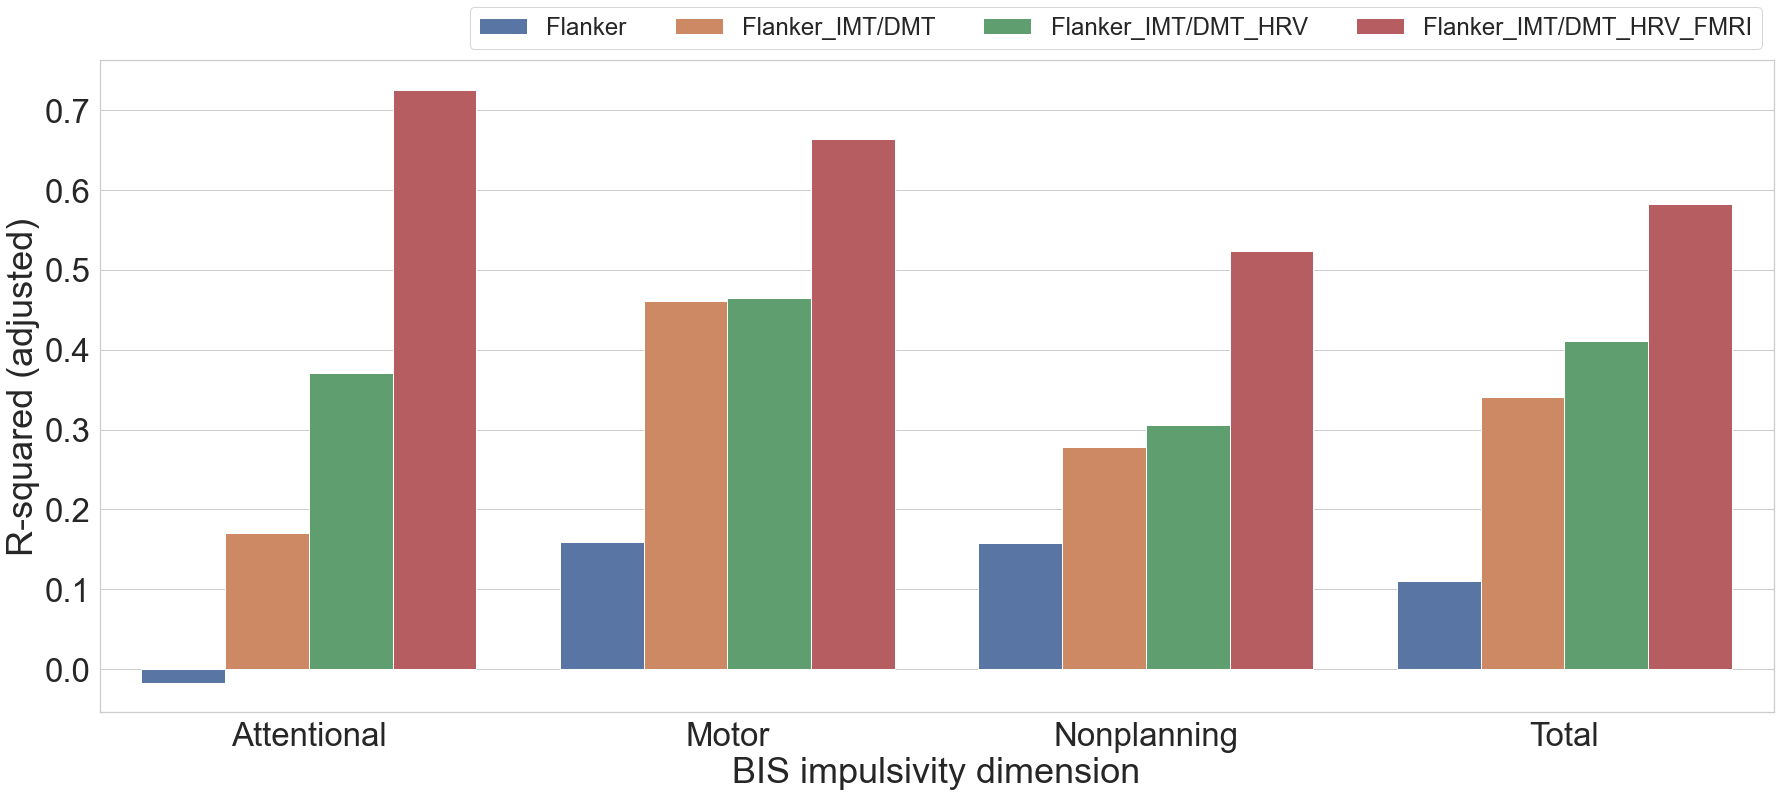

In [48]:
sns.set(font_scale=3,style='whitegrid')

fig, ax = plt.subplots(figsize=(30,12))

sel_feat_start_sel = ['Flanker', 'Flanker_IMT/DMT', 
       'Flanker_IMT/DMT_HRV', 
       'Flanker_IMT/DMT_HRV_FMRI']
sel_result     = all_results_ols_pd[all_results_ols_pd.feats.isin(sel_feat_start_sel)]

sns.barplot(x='label',y='rsquared_adj',hue='feats',data=sel_result,ax=ax)
_ = plt.xticks(rotation=0)
ax.set_ylabel(' ')
ax.set_xlabel(' ')
    

plt.legend(ncol=4,bbox_to_anchor=(1.0, 1.1),fontsize=24) 
#plt.legend([],[], frameon=False)
ax.set_xlabel('BIS impulsivity dimension')
ax.set_ylabel('R-squared (adjusted)')
#plt.savefig('../results_images/multimodal_bis_ols_rsquared_all.png',bbox_inches='tight')

### Do other modality complement FMRI

Text(0, 0.5, 'R-squared (adjusted)')

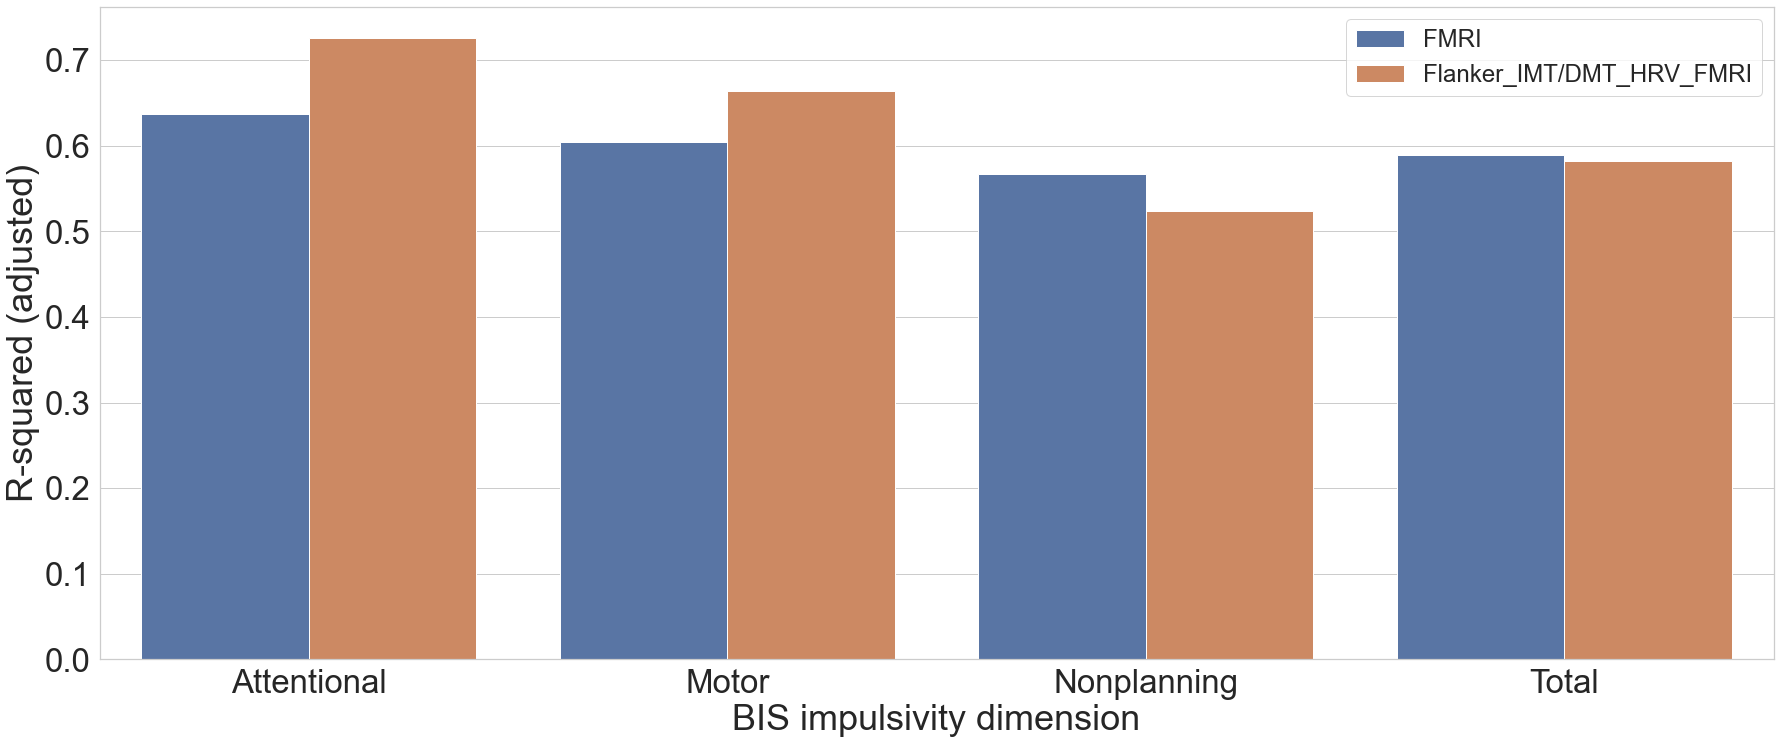

In [49]:
sel_feat_start_comp     = ['FMRI','Flanker_IMT/DMT_HRV_FMRI'] 
#['Flanker','Flanker_IMT/DMT','Flanker_IMT/DMT_HRV','Flanker_IMT/DMT_HRV_FMRI']    
all_results_ols_pd_sel  = all_results_ols_pd[all_results_ols_pd.feats.isin(sel_feat_start_comp)].copy()

sns.set(font_scale=3,style='whitegrid')

fig, ax = plt.subplots(figsize=(30,12))

sns.barplot(x='label',y='rsquared_adj',hue='feats',
            data=all_results_ols_pd_sel,ax=ax)
_ = plt.xticks(rotation=0)
ax.set_ylabel(' ')
ax.set_xlabel(' ')
    

plt.legend(ncol=1,bbox_to_anchor=(1.0, 1.0),fontsize=24) 
#plt.legend([],[], frameon=False)
ax.set_xlabel('BIS impulsivity dimension')
ax.set_ylabel('R-squared (adjusted)')
#plt.savefig('../results_images/multimodal_bis_ols_rsquared_flankerStart.png',bbox_inches='tight')

### Plot multiple analysis together

In [50]:
from matplotlib.gridspec import GridSpec
import colorcet as cc

In [51]:
all_feats = all_results_ols_pd.feats.unique()

In [52]:
all_combination_used = sorted(list(set(['IMT/DMT','HRV','FMRI','IMT/DMT_HRV','IMT/DMT_FMRI','HRV_FMRI','IMT/DMT_HRV_FMRI'] + 
['Flanker','FMRI','Flanker_FMRI'] + 
['IMT/DMT','HRV','FMRI','IMT/DMT_HRV','IMT/DMT_FMRI','HRV_FMRI','IMT/DMT_HRV_FMRI'] + 
['HRV','FMRI','HRV_FMRI'] + 
['FMRI','Flanker_IMT/DMT_HRV'] + 
['Flanker', 'Flanker_IMT/DMT', 'Flanker_IMT/DMT_HRV', 'Flanker_IMT/DMT_HRV_FMRI'])))

In [53]:
use_palette                    = sns.color_palette('Paired', n_colors=12)
all_combination_used_color     = list(use_palette)

In [54]:
feat_color = dict(zip(all_combination_used,all_combination_used_color))

In [55]:
sel_feat_start_sel = ['FMRI','Flanker_IMT/DMT_HRV','Flanker_IMT/DMT_HRV_FMRI']
sel_result     = all_results_ols_pd[all_results_ols_pd.feats.\
                                    isin(sel_feat_start_sel)].copy()
sel_result['feats'] = sel_result['feats'].apply(lambda x:{'FMRI':'FMRI',
                                                         'Flanker_IMT/DMT_HRV':'Non-FMRI',
                                                         'Flanker_IMT/DMT_HRV_FMRI':'Combined'}[x])
sel_result.sort_values(by='feats')

,feats,label,rsquared,rsquared_adj,pval_overall
160,Combined,Attentional,0.786817,0.725907,0.000130
161,Combined,Motor,0.738247,0.663461,0.000519
162,Combined,Nonplanning,0.629820,0.524055,0.005152
163,Combined,Total,0.675285,0.582509,0.002180
12,FMRI,Attentional,0.656781,0.636591,0.000026
13,FMRI,Motor,0.626232,0.604245,0.000054
14,FMRI,Nonplanning,0.591383,0.567347,0.000119
15,FMRI,Total,0.611920,0.589091,0.000076
64,Non-FMRI,Attentional,0.475355,0.370426,0.018804
65,Non-FMRI,Motor,0.554378,0.465254,0.005878


In [56]:
sel_result     = all_results_ols_pd[all_results_ols_pd.feats.\
                                    isin(sel_feat_start_sel)].copy()


In [57]:
from collections import OrderedDict

Text(0.02, 0.5, 'R-squared (adjusted)')

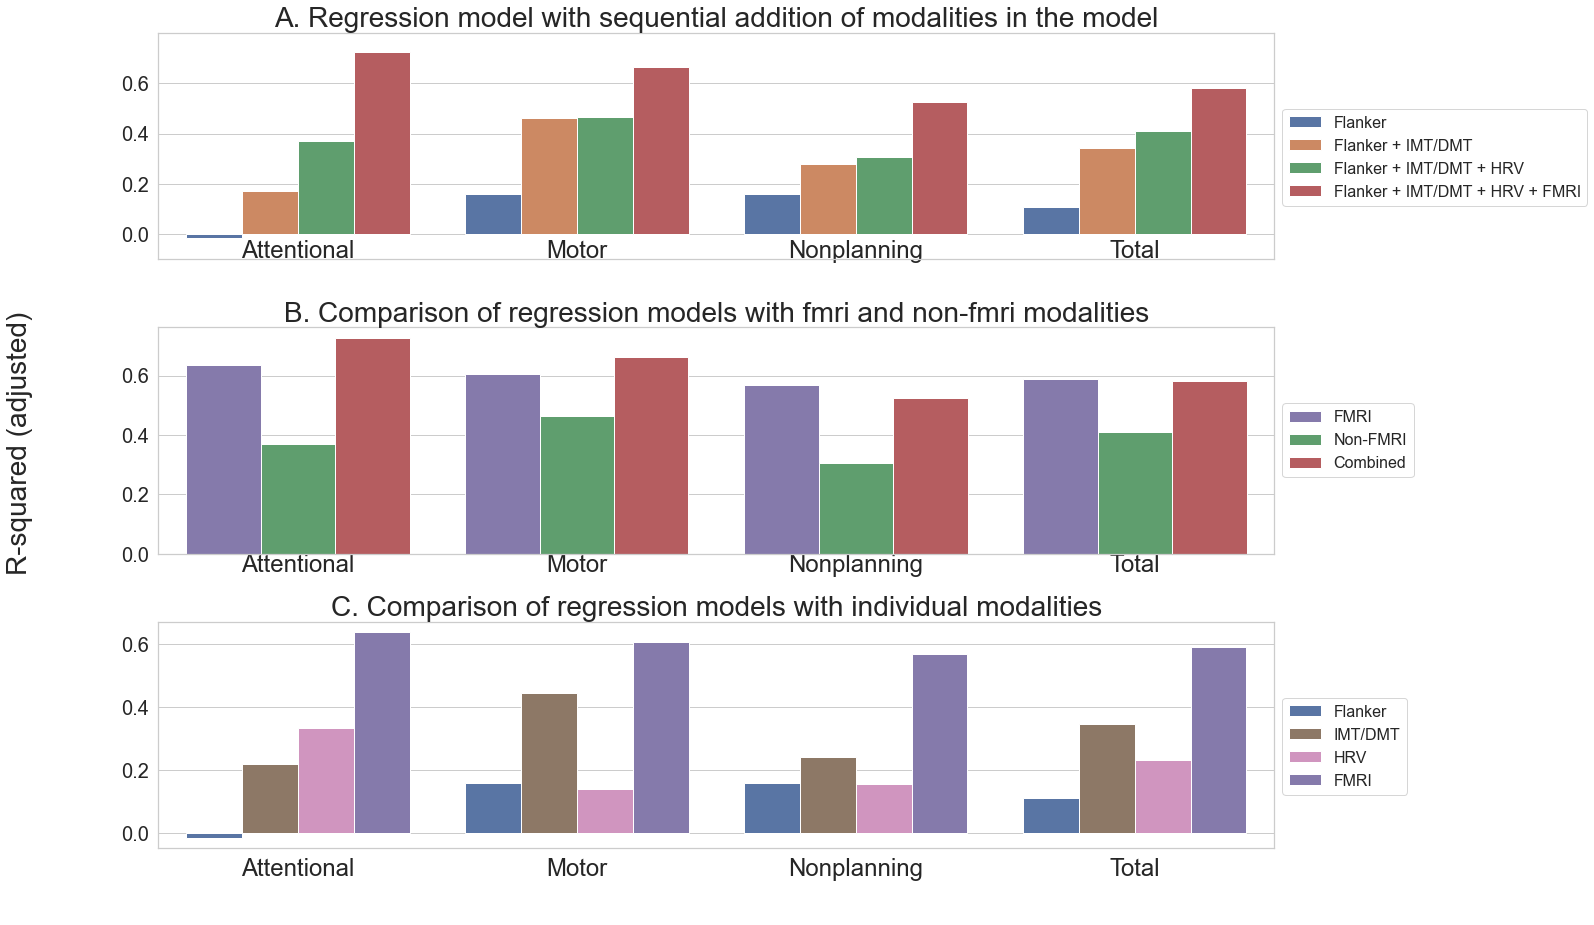

In [58]:
def_color_palette = iter(sns.color_palette())
plot_colors_all = OrderedDict()

sns.set(font_scale=3,style='whitegrid')

fig = plt.figure(figsize=(20,15))
gs  = GridSpec(3,1,figure=fig)

#top panel
ax1 = fig.add_subplot(gs[0])
#bottom left panel
ax2 = fig.add_subplot(gs[1])
#bottom right panel
ax3 = fig.add_subplot(gs[2])

#top panel :- sequentially add modality based on cost/complexity
sel_feat_start_sel = ['Flanker', 'Flanker_IMT/DMT', 
                       'Flanker_IMT/DMT_HRV', 
                       'Flanker_IMT/DMT_HRV_FMRI']

#sel_feat_start_sel_color = ['r','g','b','k']# [feat_color[x] for x in sel_feat_start_sel]

sel_result     = all_results_ols_pd[all_results_ols_pd.feats.\
                                    isin(sel_feat_start_sel)].copy()

sel_result_map = {'Flanker':'Flanker', 'Flanker_IMT/DMT':'Flanker + IMT/DMT', 
                       'Flanker_IMT/DMT_HRV':'Flanker + IMT/DMT + HRV', 
                       'Flanker_IMT/DMT_HRV_FMRI':'Flanker + IMT/DMT + HRV + FMRI'}

sel_result['feats']    = sel_result['feats'].apply(lambda x:sel_result_map[x])
sel_feat_start_sel_map = [sel_result_map[x] for x in sel_feat_start_sel]

sequential_modality_color_plot = []
for each_key in sel_feat_start_sel_map:
    curr_color = next(def_color_palette)
    sequential_modality_color_plot.append(curr_color)
    plot_colors_all[each_key] = curr_color

sns.barplot(x='label',y='rsquared_adj',hue='feats',data=sel_result,ax=ax1,
           hue_order=sel_feat_start_sel_map,palette=sequential_modality_color_plot)

ax1.set_ylabel(' ')
ax1.set_xlabel(' ')
ax1.tick_params(axis="x",direction="in", pad=-20,labelsize=24)
ax1.set_ylim(-0.1,0.8)
ax1.set_yticks(np.arange(0,0.8,0.2))
ax1.tick_params(axis='y', which='major', labelsize=20)
ax1.legend(ncol=1,fontsize=16,bbox_to_anchor=(1,0.7),bbox_transform=ax1.transAxes) 
ax1.set_title('A. Regression model with sequential addition of modalities in the model',fontsize=28)


#### -----------------

#left panel :- fmri vs non-fmri modalities
sel_feat_start_sel = ['FMRI','Flanker_IMT/DMT_HRV','Flanker_IMT/DMT_HRV_FMRI']
sel_result         = all_results_ols_pd[all_results_ols_pd.feats.\
                                    isin(sel_feat_start_sel)].copy()
sel_result['feats'] = sel_result['feats'].apply(lambda x:{'FMRI':'FMRI',
                                                         'Flanker_IMT/DMT_HRV':'Non-FMRI',
                                                         'Flanker_IMT/DMT_HRV_FMRI':'Combined'}[x])

fmri_nonFmri_color = [next(def_color_palette),sequential_modality_color_plot[2],
                      sequential_modality_color_plot[3]]

sns.barplot(x='label',y='rsquared_adj',hue='feats',data=sel_result,ax=ax2,palette=fmri_nonFmri_color)

ax2.set_ylabel(' ')
ax2.set_xlabel(' ')
ax2.legend(ncol=1,fontsize=16,
          bbox_transform=ax2.transAxes, bbox_to_anchor=(1.0,0.7)) 
ax2.tick_params(axis="x",direction="in", pad=0,labelsize=24)
ax2.set_yticks(np.arange(0,0.8,0.2))
ax2.tick_params(axis='y', which='major', labelsize=20)
ax2.set_title('B. Comparison of regression models with fmri and non-fmri modalities',fontsize=28)


#comparison of all modalities

sel_feat_start_sel = ['Flanker','IMT/DMT','HRV','FMRI'] #['HRV','FMRI','HRV_FMRI']

sel_result     = all_results_ols_pd[(all_results_ols_pd.feats.isin(sel_feat_start_sel))].copy()

indiv_modality_palette = [sequential_modality_color_plot[0],next(def_color_palette),next(def_color_palette),
                         fmri_nonFmri_color[0]]

sns.barplot(x='label',y='rsquared_adj',hue='feats',data=sel_result,ax=ax3,palette=indiv_modality_palette)

ax3.set_ylabel(' ')
ax3.set_xlabel(' ')
ax3.tick_params('x', labelrotation=0,labelsize=24) 
ax3.get_legend().remove()
#ax3.legend(ncol=1,fontsize=16,bbox_to_anchor=(1.0,0.8,0.65,0.1),mode='expand',bbox_transform=ax3.transAxes) 
ax3.legend(ncol=1,fontsize=16,bbox_transform=ax3.transAxes, bbox_to_anchor=(1.0,0.7)) 
ax3.set_yticks(np.arange(0,0.8,0.2))
ax3.tick_params(axis='y', which='major', labelsize=20)
ax3.set_title('C. Comparison of regression models with individual modalities',fontsize=28)

plt.subplots_adjust(hspace=0.3)
plt.subplots_adjust(wspace=-0.1)

fig.supylabel('R-squared (adjusted)',fontsize=28)

#plt.savefig('../results_images/multimodal_bis_ols_rsquared_allexp_3panel.png',bbox_inches='tight')

### predict the impulsivity for held-out patient

In [59]:
bis_cols_numquest = {'BIS-AttentionalImpuls_2order_score':8,
 'BIS-MotorImpuls_2order_score':11,
 'BIS-NonPlanning_2order_score':11,
 'BIS-total_score':30}

In [60]:
from scipy.io import loadmat
from scipy.stats import ttest_ind, pearsonr

In [61]:
fmri_res_file = r'data/resultsROI_Condition001.mat'

In [62]:
fmri_res_dict = loadmat(fmri_res_file)
fmri_roi_name = fmri_res_dict['names2'][0]
fmri_roi_Z    = fmri_res_dict['Z']

fmri_roi_name_short_ = np.array([('.'.join(x[0].split('.')[-2:])) for x in fmri_roi_name])
fmri_roi_name_short  = np.array([ ' ('.join(x.split('(')[:-1]) if '(' in x else x for x in fmri_roi_name_short_])

In [63]:
# Z-score and correlation coefficient are related by: z’ = .5[ln(1+r) – ln(1-r)]

#Z(i,j) = tanh−1(r(i,j)) #fisher transformed 

In [64]:
fmri_subjmapping_file = r'data/subjmapping_35subj.xlsx'
fmri_subjmapping_pd   = pd.read_excel(fmri_subjmapping_file).sort_values(by='Subject')
print(fmri_subjmapping_pd.shape)
fmri_subjmapping_pd.head()

(30, 2)


,Subject,MIND-ID
0,1,P-001
1,2,P-002
2,3,P-003
3,4,P-004
4,5,P-005


In [65]:
sel_seed      = 'Salience.ACC '
feat_idx      = np.where(fmri_roi_name_short==sel_seed)[0]
acc_conn_feat = fmri_roi_Z[feat_idx,:,:].squeeze().transpose()

In [66]:
# subject X ROI
acc_conn_feat.shape

(30, 167)

In [67]:
acc_conn_feat_pd = pd.DataFrame(acc_conn_feat,
                               columns=fmri_roi_name_short)

In [68]:
acc_conn_feat_pd['MIND-ID'] = fmri_subjmapping_pd['MIND-ID'].copy()

In [69]:
multimodal_pd.head()

,MIND-ID,BIS-AttentionalImpuls_2order_score,BIS-MotorImpuls_2order_score,BIS-NonPlanning_2order_score,BIS-total_score,error_rate,IMT_comm_error_to_corr_det,DMT_comm_error_to_corr_det,sdrr,rmssd,pnn_50,pnn_20,bis_attentionalimpulsivity_Salience.ACC_results.ROIs.+48 +40 +26,bis_motorimpulsivity_Salience.ACC_results.ROIs.+4 -76 +2,bis_nonplanning_Salience.ACC_results.ROIs.-20 -18 +72,bis_totalscore_Salience.ACC_results.ROIs.-22 -18 +72
0,P-005,12,21,20,53,0.082759,0.467977,0.214293,3.364594,2.969136,1.723064,11.487160,-0.2559,0.2007,0.1860,0.1631
1,P-006,14,16,20,50,0.117241,0.329984,0.735550,3.271096,3.255902,4.709910,13.236980,0.0169,0.2488,0.3698,0.4164
2,P-009,21,24,24,69,0.234483,0.538899,0.875000,4.784572,4.971248,70.673401,83.683502,-0.0030,0.2121,0.1253,0.1424
3,P-010,19,21,21,61,0.165517,0.271915,0.263771,4.375696,3.900033,23.581892,48.425693,-0.2216,-0.0152,0.3778,0.2802
4,P-011,23,25,18,66,0.089655,0.290925,0.500054,4.264711,3.862795,26.382091,53.577924,0.2773,0.1350,0.0479,0.0783


In [70]:
multimodal_pd.shape

(19, 16)

In [71]:
feat_all_classification = {'Flanker':['error_rate'],
            'IMT/DMT':['IMT_comm_error_to_corr_det','DMT_comm_error_to_corr_det'],
            'HRV':['sdrr','rmssd','pnn_50','pnn_20'],
           'FMRI':list(fmri_roi_name_short)}

In [72]:
how_merge      = 'inner' #default = inner
multimodal_pd_classification = quest_pd[['MIND-ID']+bis_cols].merge(flanker_pd[['MIND-ID'] + feat_all_classification['Flanker']],
                                                on='MIND-ID',how=how_merge).\
                    merge(imtdmt_pd[['MIND-ID'] + feat_all_classification['IMT/DMT']],on='MIND-ID',how=how_merge).\
                    merge(hrv_pd[['MIND-ID']+ feat_all_classification['HRV']],on='MIND-ID',how=how_merge).\
                    merge(acc_conn_feat_pd[['MIND-ID']+feat_all_classification['FMRI']],on='MIND-ID',how=how_merge)

In [73]:
multimodal_pd_classification.shape

(19, 179)

In [74]:
def feat_selection(input_feat,input_label):
    pval_thr = 0.05

    sel_feat = []
    
    for feat_idx in np.arange(input_feat.shape[1]):
        curr_feat                           = input_feat[:,feat_idx].squeeze()
        for each_label in input_label.columns:
            curr_feat_corr, curr_feat_corrpval  = pearsonr(curr_feat,input_label[each_label].squeeze())

            if(curr_feat_corrpval < pval_thr):
                sel_feat.append(feat_idx)
                break

    return sel_feat

In [75]:
sel_clf = ridge

use_feat_selection      = False
sel_fmri_feat           = True
num_fmri_feat_perimpuls = 2

feat_res_all = []

for curr_quest_col in bis_cols:
    
    quest_col_name = curr_quest_col.split('_')[0].split('-')[-1]
    
    feat_res = []
       
    for idx,feat in  enumerate([['Flanker'],['Flanker','IMT/DMT'],
                           ['Flanker','IMT/DMT','HRV'],
                           ['Flanker','IMT/DMT','HRV','FMRI'],
                               ['FMRI'],['Flanker','IMT/DMT','HRV'],
                            ['FMRI'],['HRV','FMRI'],['Flanker','FMRI'], ['IMT/DMT','FMRI']]):
        sel_feat = []
        for feat_ in feat:
            if(feat_ == 'FMRI'):
                sel_feat = sel_feat + feat_all_classification[feat_]
            else:
                sel_feat = sel_feat + feat_all_classification[feat_]
    
        feat_data      = multimodal_pd_classification[sel_feat]
        label_data_all = multimodal_pd_classification[curr_quest_col]
        
        pca = PCA() #(n_components=2)

        true_label      = []
        pred_label_clf  = []
        subj_name       = []
        pred_label_mean = []

        for train_idx, test_idx in loo.split(feat_data,label_data_all):
            train_feat = feat_data.iloc[train_idx,:]
            test_feat  = feat_data.iloc[test_idx,:]

            train_label= label_data_all.iloc[train_idx]
            test_label = label_data_all.iloc[test_idx]
            test_subj  = feat_data.iloc[test_idx].index[0]
            
            #if fmri are included, only include max_fmri_feat connectivity with strongest correlation with a impulsivity dimension
            if(sel_fmri_feat and 'FMRI' in feat):
                train_fmri_feat = train_feat[list(fmri_roi_name_short)]
                train_fmri_label= train_label

                all_corr        = train_fmri_feat.corrwith(train_label)    
                fmri_sel_feat   = all_corr.abs().sort_values().dropna()[-num_fmri_feat_perimpuls:].index.values.squeeze()

                drop_fmri_feat = np.setdiff1d(fmri_roi_name_short,fmri_sel_feat)

                #drop the other features
                train_feat     = train_feat.drop(drop_fmri_feat,axis=1)
                test_feat      = test_feat.drop(drop_fmri_feat,axis=1)

            
            train_feat = mean_imputer.fit_transform(train_feat)
            test_feat  = mean_imputer.transform(test_feat)
            
            #normalization
            #train_feat = minmax_scaler.fit_transform(train_feat)
            #test_feat  = minmax_scaler.transform(test_feat)    

            sel_clf.fit(train_feat,train_label)

            pred_clf = sel_clf.predict(test_feat)
            
            #maximum/minimum of the questionnaire
            pred_clf = np.max([pred_clf[0],bis_cols_numquest[curr_quest_col]*1])
            pred_clf = np.min([pred_clf,bis_cols_numquest[curr_quest_col]*4]) 

            true_label.append(test_label.values)
            pred_label_clf.append([pred_clf])
            subj_name.append(test_subj)
            pred_label_mean.append(np.mean(train_label))

        true_label_np      = np.concatenate(true_label)
        pred_label_clf_np   = np.concatenate(pred_label_clf)
        subj_name_np       = np.array(subj_name)

     
        pred_label_mean_np = np.array(pred_label_mean)
        clf_rmse           = np.sqrt(mean_squared_error(true_label_np,pred_label_clf_np))
        norm_factor_rmse   = (np.max(true_label_np) - np.min(true_label_np)) #np.std(true_label_np) 
        clf_nrmse          = clf_rmse/norm_factor_rmse
        
        mean_rmse    = np.sqrt(mean_squared_error(true_label_np,pred_label_mean_np))
        mean_nrmse   = mean_rmse/norm_factor_rmse 
        
        feat_res.append({'feat':'_'.join(feat),
                                     'clf_rmse':clf_rmse,
                                     'clf_nrmse':clf_nrmse,
                                     'col':quest_col_name})

        print('Analyzed {}'.format(feat))
        
     
    feat_res.append({'feat':'Mean_baseline','clf_rmse':mean_rmse,'clf_nrmse':mean_nrmse,'col':quest_col_name})
    
    for each_feat in feat_res:
        feat_res_all.append(each_feat.copy())

    feat_res_pd = pd.DataFrame(feat_res)

Analyzed ['Flanker']
Analyzed ['Flanker', 'IMT/DMT']
Analyzed ['Flanker', 'IMT/DMT', 'HRV']
Analyzed ['Flanker', 'IMT/DMT', 'HRV', 'FMRI']
Analyzed ['FMRI']
Analyzed ['Flanker', 'IMT/DMT', 'HRV']
Analyzed ['FMRI']
Analyzed ['HRV', 'FMRI']
Analyzed ['Flanker', 'FMRI']
Analyzed ['IMT/DMT', 'FMRI']
Analyzed ['Flanker']
Analyzed ['Flanker', 'IMT/DMT']
Analyzed ['Flanker', 'IMT/DMT', 'HRV']
Analyzed ['Flanker', 'IMT/DMT', 'HRV', 'FMRI']
Analyzed ['FMRI']
Analyzed ['Flanker', 'IMT/DMT', 'HRV']
Analyzed ['FMRI']
Analyzed ['HRV', 'FMRI']
Analyzed ['Flanker', 'FMRI']
Analyzed ['IMT/DMT', 'FMRI']
Analyzed ['Flanker']
Analyzed ['Flanker', 'IMT/DMT']
Analyzed ['Flanker', 'IMT/DMT', 'HRV']
Analyzed ['Flanker', 'IMT/DMT', 'HRV', 'FMRI']
Analyzed ['FMRI']
Analyzed ['Flanker', 'IMT/DMT', 'HRV']
Analyzed ['FMRI']
Analyzed ['HRV', 'FMRI']
Analyzed ['Flanker', 'FMRI']
Analyzed ['IMT/DMT', 'FMRI']
Analyzed ['Flanker']
Analyzed ['Flanker', 'IMT/DMT']
Analyzed ['Flanker', 'IMT/DMT', 'HRV']
Analyzed ['Flanke

In [76]:
feat_res_all_pd_ridge = pd.DataFrame(feat_res_all)
feat_res_all_pd_ridge.head()

,feat,clf_rmse,clf_nrmse,col
0,Flanker,5.509579,0.306088,AttentionalImpuls
1,Flanker_IMT/DMT,4.865308,0.270295,AttentionalImpuls
2,Flanker_IMT/DMT_HRV,4.052690,0.225149,AttentionalImpuls
3,Flanker_IMT/DMT_HRV_FMRI,3.783515,0.210195,AttentionalImpuls
4,FMRI,5.332001,0.296222,AttentionalImpuls


In [77]:
feat_res_all_pd_ridge.head()

,feat,clf_rmse,clf_nrmse,col
0,Flanker,5.509579,0.306088,AttentionalImpuls
1,Flanker_IMT/DMT,4.865308,0.270295,AttentionalImpuls
2,Flanker_IMT/DMT_HRV,4.052690,0.225149,AttentionalImpuls
3,Flanker_IMT/DMT_HRV_FMRI,3.783515,0.210195,AttentionalImpuls
4,FMRI,5.332001,0.296222,AttentionalImpuls


In [78]:
feat_res_all_pd_ridge_pivot = feat_res_all_pd_ridge.pivot_table(index=['col'],values=['clf_nrmse'],
                                                               columns='feat')

In [79]:
feat_res_all_pd_ridge_pivot.columns = feat_res_all_pd_ridge_pivot.columns.droplevel()

In [80]:
feat_res_all_pd_ridge_pivot['Non-FMRI'] = feat_res_all_pd_ridge_pivot['Flanker_IMT/DMT_HRV'].copy()

In [81]:
feat_res_all_pd_ridge_pivot.columns.values

array(['FMRI', 'Flanker', 'Flanker_FMRI', 'Flanker_IMT/DMT',
       'Flanker_IMT/DMT_HRV', 'Flanker_IMT/DMT_HRV_FMRI', 'HRV_FMRI',
       'IMT/DMT_FMRI', 'Mean_baseline', 'Non-FMRI'], dtype=object)

In [82]:
feat_res_all_pd_ridge_pivot = feat_res_all_pd_ridge_pivot[['Mean_baseline',
        'Flanker','Flanker_IMT/DMT', 'Flanker_IMT/DMT_HRV','Flanker_IMT/DMT_HRV_FMRI',
        'FMRI','Non-FMRI',
        'Flanker_FMRI', 'HRV_FMRI','IMT/DMT_FMRI']]

In [83]:
print(feat_res_all_pd_ridge_pivot.to_latex(float_format="{:0.2f}".format))

\begin{tabular}{lrrrrrrrrrr}
\toprule
feat &  Mean\_baseline &  Flanker &  Flanker\_IMT/DMT &  Flanker\_IMT/DMT\_HRV &  Flanker\_IMT/DMT\_HRV\_FMRI &  FMRI &  Non-FMRI &  Flanker\_FMRI &  HRV\_FMRI &  IMT/DMT\_FMRI \\
col               &                &          &                  &                      &                           &       &           &               &           &               \\
\midrule
AttentionalImpuls &           0.31 &     0.31 &             0.27 &                 0.23 &                      0.21 &  0.30 &      0.23 &          0.30 &      0.22 &          0.26 \\
MotorImpuls       &           0.27 &     0.27 &             0.20 &                 0.20 &                      0.20 &  0.25 &      0.20 &          0.25 &      0.23 &          0.20 \\
NonPlanning       &           0.35 &     0.35 &             0.33 &                 0.32 &                      0.25 &  0.27 &      0.32 &          0.27 &      0.25 &          0.26 \\
total             &           0.34 &     

In [84]:
print(feat_res_all_pd_ridge_pivot[['Mean_baseline',
        'Flanker','Flanker_IMT/DMT', 'Flanker_IMT/DMT_HRV','Flanker_IMT/DMT_HRV_FMRI']].to_latex(float_format="{:0.2f}".format))
print(feat_res_all_pd_ridge_pivot[['Mean_baseline','FMRI','Non-FMRI']].to_latex(float_format="{:0.2f}".format))
print(feat_res_all_pd_ridge_pivot[['Mean_baseline','Flanker_FMRI', 'HRV_FMRI','IMT/DMT_FMRI']].\
      to_latex(float_format="{:0.2f}".format))

\begin{tabular}{lrrrrr}
\toprule
feat &  Mean\_baseline &  Flanker &  Flanker\_IMT/DMT &  Flanker\_IMT/DMT\_HRV &  Flanker\_IMT/DMT\_HRV\_FMRI \\
col               &                &          &                  &                      &                           \\
\midrule
AttentionalImpuls &           0.31 &     0.31 &             0.27 &                 0.23 &                      0.21 \\
MotorImpuls       &           0.27 &     0.27 &             0.20 &                 0.20 &                      0.20 \\
NonPlanning       &           0.35 &     0.35 &             0.33 &                 0.32 &                      0.25 \\
total             &           0.34 &     0.33 &             0.28 &                 0.25 &                      0.23 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrr}
\toprule
feat &  Mean\_baseline &  FMRI &  Non-FMRI \\
col               &                &       &           \\
\midrule
AttentionalImpuls &           0.31 &  0.30 &      0.23 \\
MotorImpuls       &  